In [72]:
import torch
import torchvision
from lexplainet.implicit.rules import *

device = "cuda" if torch.cuda.is_available() else "cpu"

def model_loader(model_name, device):
    if model_name == "resnet18":
        model = torchvision.models.resnet18(pretrained=True)
    elif model_name == "resnet34":
        model = torchvision.models.resnet34(pretrained=True)
    elif model_name == "resnet50":
        model = torchvision.models.resnet50(pretrained=True)
    elif model_name == "vgg16":
        model = torchvision.models.vgg16(pretrained=True)
    elif model_name == "vgg16_bn":
        model = torchvision.models.vgg16_bn(pretrained=True)
    else:
        raise ValueError("Unsupported model name")
    
    model = model.to(device)
    model.device = device
    model.eval()
    return model

model = model_loader("vgg16_bn", device)

/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [73]:
%matplotlib inline
import matplotlib.pyplot as plt

from imagenet import IMAGENET_CLASS_NAMES
from imagenet.utils import inference_transform
from lexplainet.heatmap import show_image, load_image, plot_heatmap

Image Tensor Shape: torch.Size([1, 3, 224, 224])


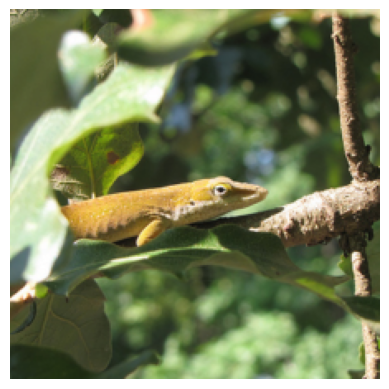

<Figure size 640x480 with 0 Axes>

In [74]:
image_tensor = load_image('./lizard.jpg', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

In [75]:
from model_utils.inference import inference, forward_pass
from model_utils.autograd import compute_relevance, make_gradient_output

In [76]:
from lexplainet.implicit.model_specific_patches import canonize_resnet, canonize_vgg_bn
from lexplainet.implicit.composite_core import patch_composite, undo_patch_all
from lexplainet.implicit.rules import gamma_rule, identity_rule, epsilon_rule, zplus_rule, lifted_gamma_rule

In [77]:
undo_patch_all(model)

composite = {
            torch.nn.Conv2d: (lifted_gamma_rule, {'gamma': 1000.}),
            # torch.nn.Conv2d: (gamma_rule, {'gamma': 1000.}), 
            # torch.nn.Conv2d: (zplus_rule, {}),
            torch.nn.ReLU: (identity_rule, {}),
            torch.nn.BatchNorm2d: (identity_rule, {}),
            torch.nn.Linear: (epsilon_rule, {})
}

# canonize_resnet(model)
canonize_vgg_bn(model)
patch_composite(model, composite)

Canonize linear and BatchNorm layers: features.0 and features.1
Canonize linear and BatchNorm layers: features.3 and features.4
Canonize linear and BatchNorm layers: features.7 and features.8
Canonize linear and BatchNorm layers: features.10 and features.11
Canonize linear and BatchNorm layers: features.14 and features.15
Canonize linear and BatchNorm layers: features.17 and features.18
Canonize linear and BatchNorm layers: features.20 and features.21
Canonize linear and BatchNorm layers: features.24 and features.25
Canonize linear and BatchNorm layers: features.27 and features.28
Canonize linear and BatchNorm layers: features.30 and features.31
Canonize linear and BatchNorm layers: features.34 and features.35
Canonize linear and BatchNorm layers: features.37 and features.38
Canonize linear and BatchNorm layers: features.40 and features.41


In [89]:
layer = model.features[40]
latent_relevance = layer.output * layer.output.grad

In [96]:
latent_relevance.sum(dim=(0, -1, -2)).argmax()

tensor(469, device='cuda:0')

Predicted class: 40, American chameleon, anole, Anolis carolinensis


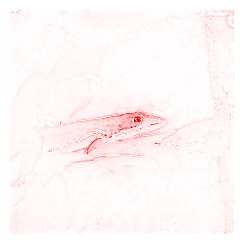

In [134]:
relevance, output = compute_relevance(model,
                            image_tensor,
                            targeted=True,
                            init_relevance=1,
                            normalize=True)

predicted_class = output.argmax(dim=1).item()
print(f"Predicted class: {predicted_class}, {IMAGENET_CLASS_NAMES[predicted_class]}")
plot_heatmap(relevance, save=False)

In [ ]:
def get_latent_relevances(layer):

    def forward_hook(module, input, output):
    
        module.output = output
        module.output.retain_grad() if module.output.requires_grad else None

    # Register the backward hook
    forward_hook_handle = layer.register_forward_hook(forward_hook)
   
    return forward_hook_handle


# there are two ways to modify the latent relevances for specific neurons:
# 1. at the level of the tensor, where we directly modify the gradients of the
#    output tensor of the layer. This is more flexible and can be used to modify    
# the relevances for specific neurons, channels, or even spatial locations.
# 2. at the level of the module, where we modify the gradients of the entire output 
# tensor of the layer. This is less flexible but can be simpler to implement. 
# In this case, we will implement both methods to show how they work. 
def modify_latent_relevances_at_tensor(concept_ids, layer):
    print(f"Modifying latent relevances for concept ids: {concept_ids} in layer: {layer}")
    def mask_fct(grad):
        # grad shape: (batch_size, num_channels, ...)
        mask = torch.zeros_like(grad)
        for batch_idx in range(grad.shape[0]):
            mask[batch_idx, concept_ids] = 1
        grad = grad * mask
        return grad

    def post_forward_hook(module, input, output):
        if output.requires_grad:
            print(f"Masking grad for output with shape: {output.shape}")
            output.register_hook(mask_fct)
        return output

    handle = layer.register_forward_hook(post_forward_hook)
    return handle



def modify_latent_relevances_at_module(condition_index, layer):

    def backward_hook(module, grad_output):
        num_neurons = grad_output[0].shape[1]  # assuming grad_output[0] has shape (batch_size, num_neurons, ...)

        if condition_index < num_neurons:
            mask = torch.zeros_like(grad_output[0])
            mask[:, condition_index, ...] = 1  # Keep only the relevance for the specified neuron

            # want to modify the gradient_output to only keep the relevance for the specified neuron
            modified_gradient_output = tuple(mask * g for g in grad_output)    
            return modified_gradient_output
        
    # register pre hook
    hook_handle = layer.register_full_backward_pre_hook(backward_hook)

    return hook_handle

: 

In [119]:
def get_layer_name(model, module):
    for name, mod in model.named_modules():
        if mod is module:
            return name
    return None


def show_multiple_heatmaps(heatmaps):
    num_heatmaps = len(heatmaps)
    fig, axes = plt.subplots(1, num_heatmaps, figsize=(5 * num_heatmaps, 5))
    for i, heatmap_dict in enumerate(heatmaps):
        heatmap = heatmap_dict["heatmap"]
        # make heatmap in torch tensor if it's not already
        if not isinstance(heatmap, torch.Tensor):
            heatmap = torch.tensor(heatmap)
        # check if heatmap is -1 +1 normalized
        if heatmap.min() >= -1 and heatmap.max() <= 1:
            print(f"Heatmap {i} is normalized between -1 and 1.")
        else:
            print(f"Heatmap {i} is NOT normalized between -1 and 1. Min: {heatmap.min()}, Max: {heatmap.max()}")
            # normalize
            heatmap = heatmap / torch.max(torch.abs(heatmap))
        axes[i].imshow(heatmap_dict["heatmap"], cmap="seismic", clim=(-heatmap_dict["clim"], heatmap_dict["clim"]))
        axes[i].axis("off")
        # also show conditioning info on each axes in multiple lines
        axes[i].set_title(f"Init Rel: {heatmap_dict['init_relevance']:.2f}, Layer: {heatmap_dict['layer_name']}\nPredicted class: {heatmap_dict['predicted_class']}, Neuron index: {heatmap_dict['neuron_index']}")

    plt.tight_layout()
    plt.show()


def compute_crp_heatmaps(model, image_tensor, conditioning_dictionary, init_relevance="logit", show=False):
    # heatmaps to stack
    heatmaps = []
    init_relevances = []
    for conditioning in conditioning_dictionary:
        layer = conditioning["layer"]
        neuron_index = conditioning["neuron_index"]
        predicted_class = conditioning.get("predicted_class", None)
        hook_handle_mask = modify_latent_relevances_at_module(neuron_index, layer)

        print(f"Computing relevance for layer: {get_layer_name(model, layer)}, neuron index: {neuron_index}, predicted class: {predicted_class}, init relevance: {init_relevance}")
        relevance, output = compute_relevance(model,
                                            image_tensor,
                                            targeted=True,
                                            target=predicted_class,
                                            init_relevance=init_relevance,
                                            normalize=True)
        
        if init_relevance == "logit":
            init_relevance_computed = output[0, predicted_class].item()
        else:
            init_relevance_computed = init_relevance
        init_relevances.append(init_relevance_computed)

        heatmap, clim = plot_heatmap(relevance, show=False)
        heatmaps.append({"heatmap": heatmap, "relevance": relevance, "clim": clim, "init_relevance": init_relevance_computed, "predicted_class": predicted_class, "layer_name": get_layer_name(model, layer), "neuron_index": neuron_index})
        hook_handle_mask.remove()

    if not show:
        return heatmaps
    else:
        show_multiple_heatmaps(heatmaps)

Computing relevance for layer: features.40, neuron index: 35, predicted class: 46, init relevance: logit
Computing relevance for layer: features.20, neuron index: 10, predicted class: 2, init relevance: logit
Heatmap 0 is normalized between -1 and 1.
Heatmap 1 is normalized between -1 and 1.


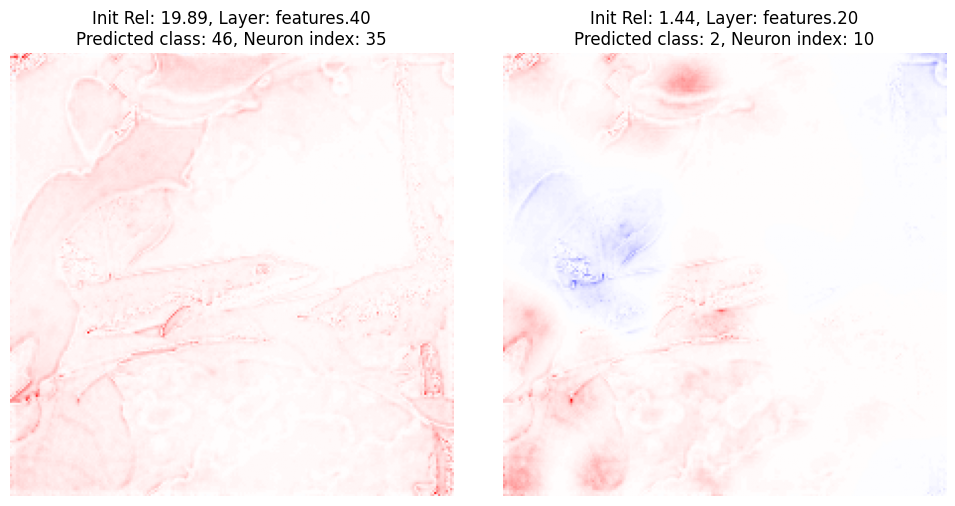

In [120]:
conditioning_dict = [{"layer":  model.features[40], "neuron_index": 35, "predicted_class": 46}, {"layer":  model.features[20], "neuron_index": 10, "predicted_class": 2}]
heatmaps = compute_crp_heatmaps(model, image_tensor, conditioning_dict, init_relevance="logit", show=True)

Computing relevance for layer: features.40, neuron index: 35, predicted class: 46, init relevance: 1
Computing relevance for layer: features.20, neuron index: 10, predicted class: 2, init relevance: 1
Heatmap 0 is normalized between -1 and 1.
Heatmap 1 is normalized between -1 and 1.


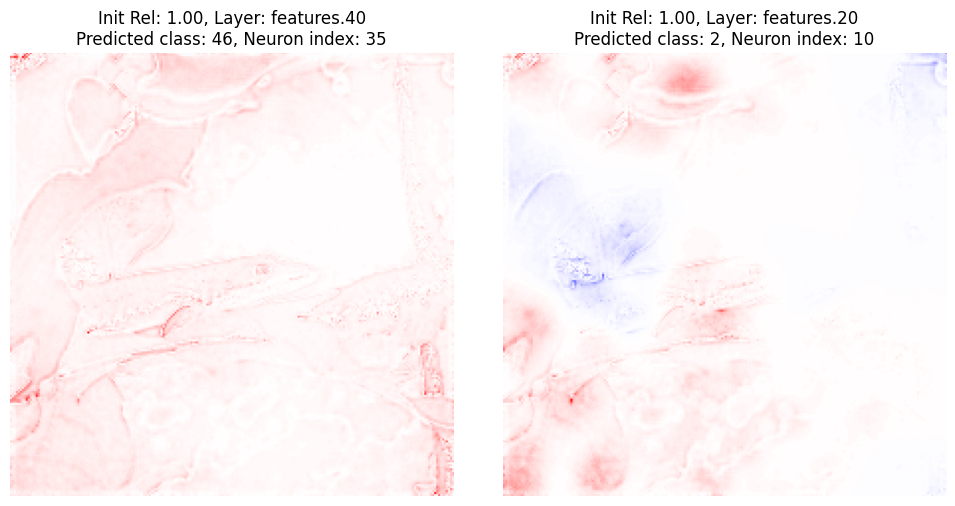

In [121]:
conditioning_dict = [{"layer":  model.features[40], "neuron_index": 35, "predicted_class": 46}, {"layer":  model.features[20], "neuron_index": 10, "predicted_class": 2}]
heatmaps = compute_crp_heatmaps(model, image_tensor, conditioning_dict, init_relevance=1, show=True)

Computing relevance for layer: features.40, neuron index: 10, predicted class: 46, init relevance: -1
Computing relevance for layer: features.40, neuron index: 10, predicted class: 2, init relevance: -1
Heatmap 0 is normalized between -1 and 1.
Heatmap 1 is normalized between -1 and 1.


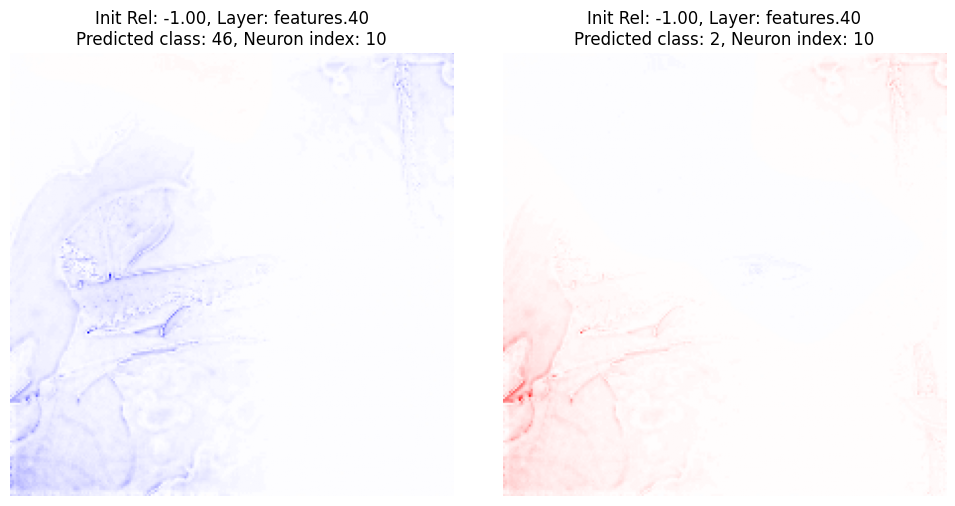

In [122]:
conditioning_dict = [{"layer":  model.features[40], "neuron_index": 10, "predicted_class": 46}, {"layer":  model.features[40], "neuron_index": 10, "predicted_class": 2}]
heatmaps = compute_crp_heatmaps(model, image_tensor, conditioning_dict, init_relevance=-1, show=True)

In [123]:
layer = model.features[40]
num_neurons = layer.out_channels if type(layer) == torch.nn.Conv2d else layer.out_features
num_neurons

512

In [129]:
layer_to_investige = model.features[40]
predicted_class = 46
conditioning_dict = [{"layer": layer_to_investige, "neuron_index": neuron_index, "predicted_class": predicted_class} for neuron_index in range(num_neurons)]

In [130]:
def compute_crp_heatmaps_with_latent(model, image_tensor, conditioning_dictionary, init_relevance="logit", show=False):
    # heatmaps to stack
    heatmaps = []
    init_relevances = []
    # attach a hook to get latent_relevances

    for conditioning in conditioning_dictionary:
        layer = conditioning["layer"]
        neuron_index = conditioning["neuron_index"]
        predicted_class = conditioning.get("predicted_class", None)
        
        storing_hook_handle = get_latent_relevances(conditioning_dictionary[0]["layer"])
        hook_handle_mask = modify_latent_relevances_at_module(neuron_index, layer)
        

        print(f"Computing relevance for layer: {get_layer_name(model, layer)}, neuron index: {neuron_index}, predicted class: {predicted_class}, init relevance: {init_relevance}")
        relevance, output = compute_relevance(model,
                                            image_tensor,
                                            targeted=True,
                                            target=predicted_class,
                                            init_relevance=init_relevance,
                                            normalize=True)
        
        
        storing_hook_handle.remove()
        hook_handle_mask.remove()

        
        if init_relevance == "logit":
            init_relevance_computed = output[0, predicted_class].item()
        else:
            init_relevance_computed = init_relevance
        init_relevances.append(init_relevance_computed)

        heatmap, clim = plot_heatmap(relevance, show=False)
        # also fetch the grad_output for the layer from the storing_dict and print its shape
        latent_relevance = layer.output * layer.output.grad
        heatmaps.append({"heatmap": heatmap, "relevance": relevance, "latent_relevance": latent_relevance, "clim": clim, "init_relevance": init_relevance_computed, "predicted_class": predicted_class, "layer_name": get_layer_name(model, layer), "neuron_index": neuron_index})
        
        storing_hook_handle.remove()
        hook_handle_mask.remove()
        
    return heatmaps

In [131]:
heatmaps = compute_crp_heatmaps_with_latent(model, image_tensor, conditioning_dict, init_relevance="logit", show=False)

Computing relevance for layer: features.40, neuron index: 0, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 1, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 2, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 3, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 4, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 5, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 6, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 7, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 8, predicted class: 46, init relevance: logit
Computing relevance for layer: features.40, neuron index: 9, pre

In [132]:
latent_relevances = torch.tensor([h["latent_relevance"].sum() for h in heatmaps])
topk_values, topk_indices = torch.topk(latent_relevances, k=6)
print("Top 5 neuron indices with highest latent relevance:", topk_indices)
print("Top 5 highest latent relevance values:", topk_values)

Top 5 neuron indices with highest latent relevance: tensor([469,  35,  71, 161,  89, 316])
Top 5 highest latent relevance values: tensor([85.2632, 48.0586, 43.3974, 18.5253, 18.5132, 15.7578])


Heatmap 0 is normalized between -1 and 1.
Heatmap 1 is normalized between -1 and 1.
Heatmap 2 is normalized between -1 and 1.
Heatmap 3 is normalized between -1 and 1.
Heatmap 4 is normalized between -1 and 1.
Heatmap 5 is normalized between -1 and 1.


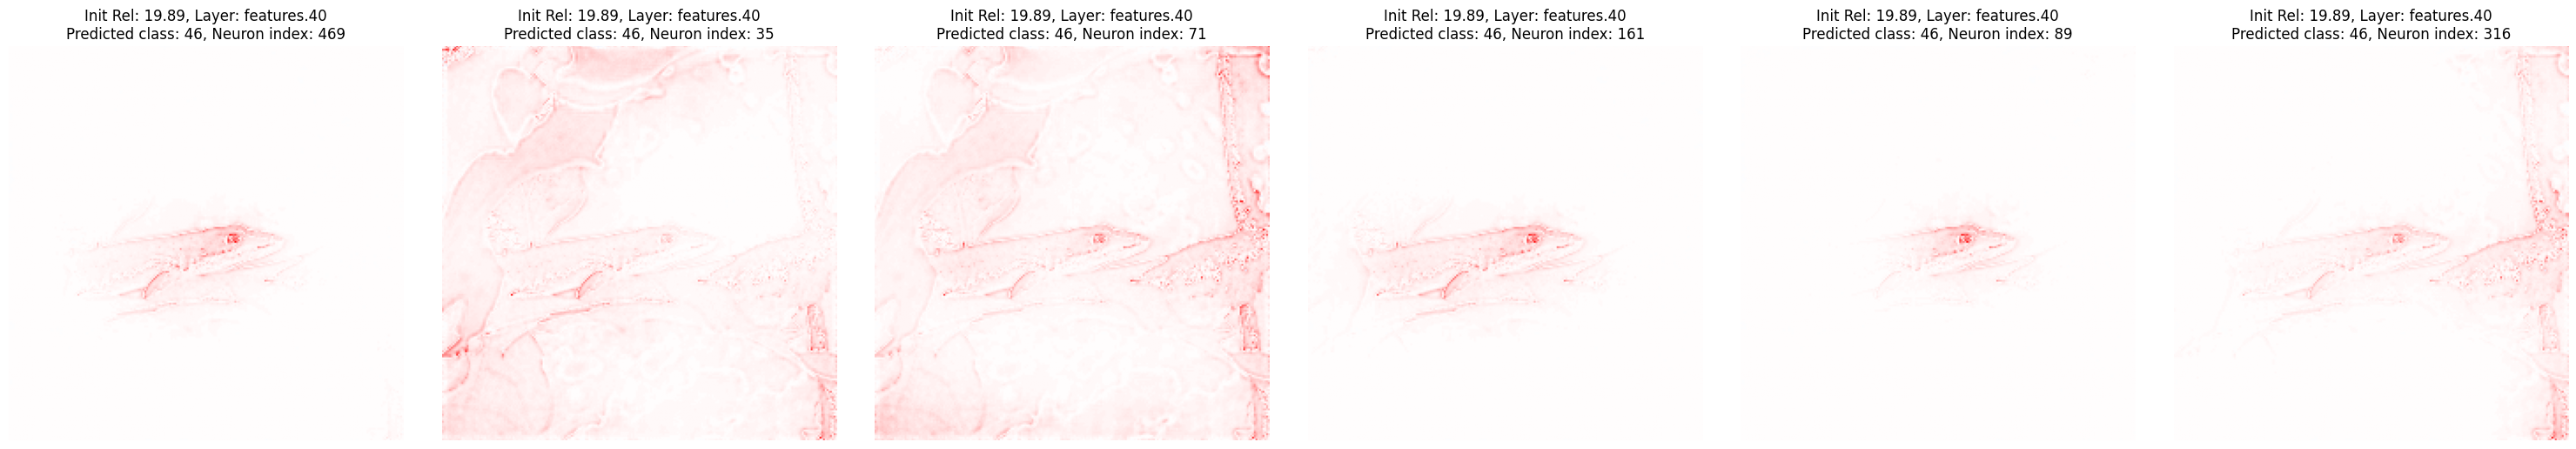

In [133]:
show_multiple_heatmaps([heatmaps[index] for index in topk_indices])